In [1]:
import sys, os, yaml
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.utils.GraphGradCAM import *


p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset
from src.models.gnn import GCNEmbeddingNet, GINEEmbeddingNet


## Caricamento modelli

In [3]:
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gcn_config.yaml")
with open(config_path) as f:
    cfg_gcn = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg_gcn["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gcn = checkpoint["node_vocab"]
rel_vocab_gcn  = checkpoint["rel_vocab"]

gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab_gcn) + 1,
    emb_dim=cfg_gcn["model"]["emb_dim"],
    hidden_dim=cfg_gcn["model"]["hidden_dim"],
    num_layers=cfg_gcn["model"]["num_layers"],
    dropout=cfg_gcn["model"]["dropout"],
    use_bbox=cfg_gcn["model"]["use_bbox"],
    node_emb_dim=cfg_gcn["model"]["node_emb_dim"],
).to(device)
gcn_model.load_state_dict(checkpoint["model_state_dict"])
gcn_model.eval()
print(f"GCN caricato da: {ckpt_path}")


GCN caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gcn20.pth


In [4]:
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg_gine = yaml.safe_load(f)

ckpt_path  = os.path.join(BASE_DIR, cfg_gine["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gine = checkpoint["node_vocab"]
rel_vocab_gine  = checkpoint["rel_vocab"]

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab_gine) + 1,
    edge_vocab_size=len(rel_vocab_gine),
    emb_dim=cfg_gine["model"]["emb_dim"],
    hidden_dim=cfg_gine["model"]["hidden_dim"],
    num_layers=cfg_gine["model"]["num_layers"],
    dropout=cfg_gine["model"]["dropout"],
    use_bbox=cfg_gine["model"]["use_bbox"],
    node_emb_dim=cfg_gine["model"]["node_emb_dim"],
).to(device)
gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()
print(f"GINE caricato da: {ckpt_path}")


GINE caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth


## Dataset di validazione

In [5]:
df_train = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["val_csv"]))

all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)

val_dataset_gcn = GQAGraphDataset(
    df=df_val, label_col="labels",
    node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)
val_dataset_gine = GQAGraphDataset(
    df=df_val, label_col="labels",
    node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

IMAGE_DIR = os.path.join(BASE_DIR, "data", "images")
print(f"Val dataset size: {len(val_dataset_gcn)}")


Val dataset size: 3208


In [6]:
train_dataset_gcn = GQAGraphDataset(
    df=df_train, label_col="labels",
    node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)

train_dataset_gine = GQAGraphDataset(
    df=df_train, label_col="labels",
    node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

print(f"Train dataset size: {len(train_dataset_gcn)}")

print("Building GCN training embeddings for prototypes...")
train_embs_gcn = build_gallery_embeddings(gcn_model, train_dataset_gcn, device, model_type="gcn")

print("Building GINE training embeddings for prototypes...")
train_embs_gine = build_gallery_embeddings(gine_model, train_dataset_gine, device, model_type="gine")

prototypes_gcn  = compute_class_prototypes(train_embs_gcn, df_train["labels"].values)
prototypes_gine = compute_class_prototypes(train_embs_gine, df_train["labels"].values)

print("Prototipi calcolati correttamente dal TRAINING SET.")


Train dataset size: 22482
Building GCN training embeddings for prototypes...
Building GINE training embeddings for prototypes...
Prototipi calcolati correttamente dal TRAINING SET.


## 1 · GraphGrad-CAM — Node Importance Aggregata per Classe

Aggreghiamo l'importanza Grad-CAM su **N campioni per classe** e mediamo per tipo di nodo.

Questo risponde alla domanda corretta:
> *"Per riconoscere oggetti della classe X, su quali tipi di nodo si concentra il modello in media?"*

L'aggregazione per tipo di nodo è necessaria perché grafi diversi hanno strutture
diverse: mediare per indice sarebbe scorretto.

In [7]:
print(label2idx)
print(idx2label)


{'a person playing a sport': 0, 'a street scene in a city': 1, 'a living room interior': 2, 'a wild animal in nature': 3, 'a food scene': 4, 'a beach scene': 5, 'a bedroom interior': 6, 'a bathroom interior': 7, 'a railway scene': 8, 'an airplane flying in the sky': 9, 'a restaurant dining scene': 10, 'a building exterior': 11, 'a kitchen interior': 12, 'a countryside landscape': 13}
{0: 'a person playing a sport', 1: 'a street scene in a city', 2: 'a living room interior', 3: 'a wild animal in nature', 4: 'a food scene', 5: 'a beach scene', 6: 'a bedroom interior', 7: 'a bathroom interior', 8: 'a railway scene', 9: 'an airplane flying in the sky', 10: 'a restaurant dining scene', 11: 'a building exterior', 12: 'a kitchen interior', 13: 'a countryside landscape'}


In [8]:
TARGET_CLASSES        = [5, 4]
NUM_SAMPLES_PER_CLASS = 100


In [9]:
with GraphGradCAM(gcn_model,  gcn_model.convs[-1])  as cam_gcn, \
     GraphGradCAM(gine_model, gine_model.convs[-1]) as cam_gine:

    results_gcn = aggregate_node_importance_by_class(
        cam=cam_gcn,
        dataset=val_dataset_gcn,
        node_vocab=node_vocab_gcn,
        df=df_val,
        target_classes=TARGET_CLASSES,
        prototypes=prototypes_gcn,
        device=device,
        num_samples_per_class=NUM_SAMPLES_PER_CLASS,
        use_edge_attr=False,
    )

    results_gine = aggregate_node_importance_by_class(
        cam=cam_gine,
        dataset=val_dataset_gine,
        node_vocab=node_vocab_gine,
        df=df_val,
        target_classes=TARGET_CLASSES,
        prototypes=prototypes_gine,
        device=device,
        num_samples_per_class=NUM_SAMPLES_PER_CLASS,
        use_edge_attr=True,
    )

print("Hook rimossi e mappe basate su prototipi calcolate.")


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
p:\Anaconda\envs\torch_new\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
p:\Uni\mujoco\dl26-projects\src\utils\GraphGradCAM.py:97: RuntimeWarning: Gradienti nulli per questo sample: importanza posta a zero.
  warnings.warn("Gradienti nulli per questo sample: importanza posta a zero.", RuntimeWarning)


Hook rimossi e mappe basate su prototipi calcolate.


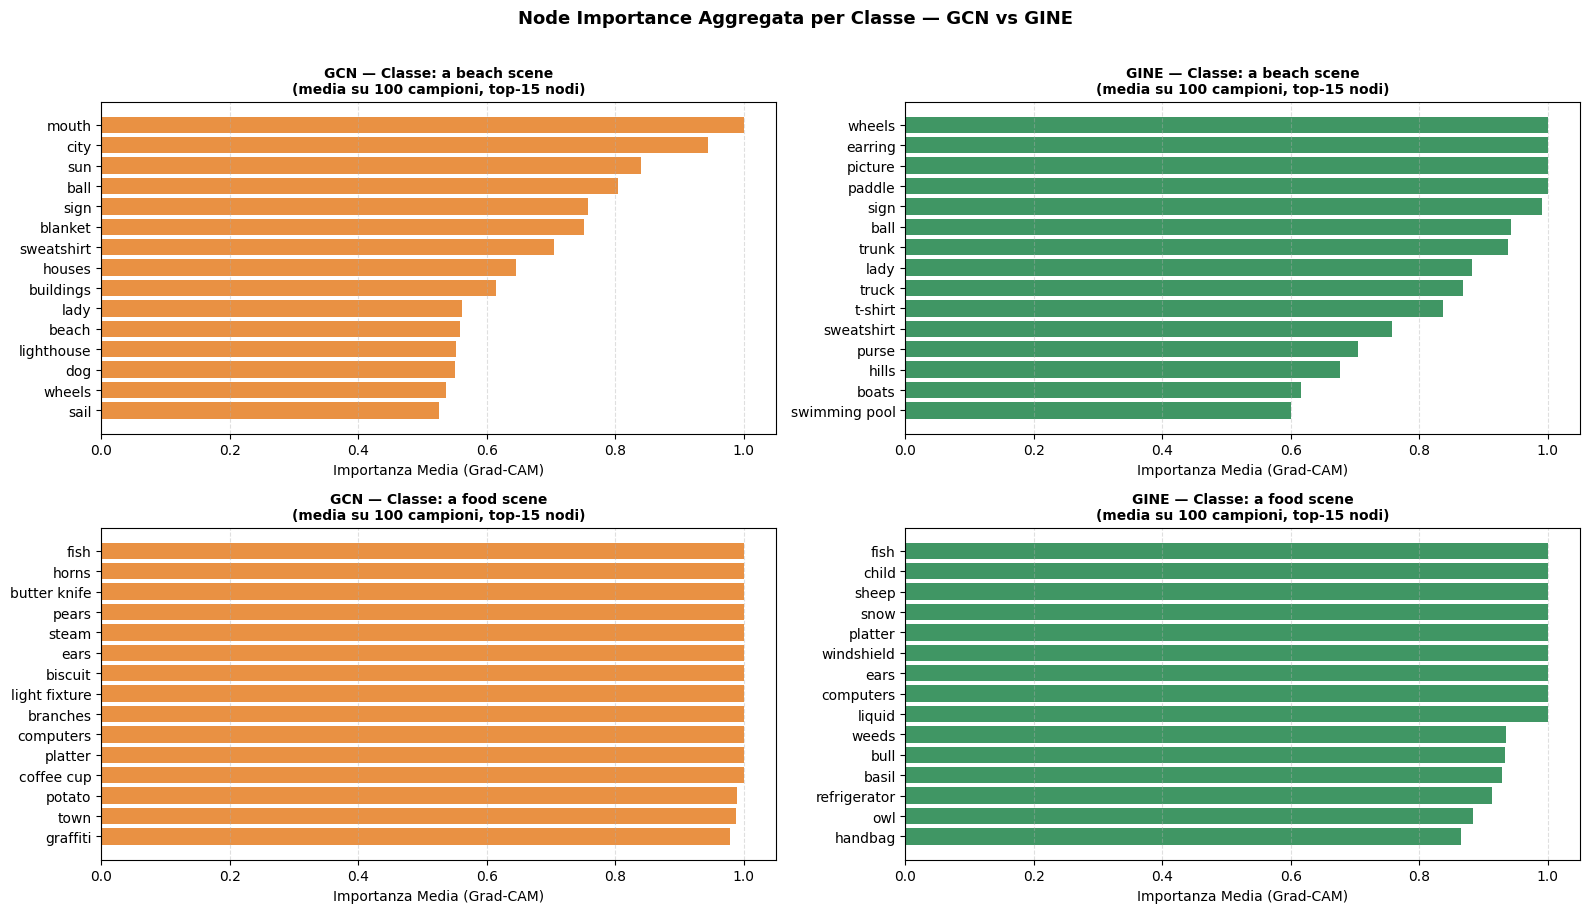

In [10]:
plot_node_importance_by_class(
    results_gcn=results_gcn,
    results_gine=results_gine,
    idx2label=idx2label,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,
    topk=15,
)


## 2 · Studio Globale Archi — GINE (GNNExplainer)

GNNExplainer ottimizza una edge mask per ogni sample e spiega quale sottoinsieme
di archi è sufficiente a riprodurre l'output. Aggregando su più campioni otteniamo
una stima dell'importanza media per tipo di relazione.

**Campionamento stratificato per classe attivato** — i campioni sono distribuiti
equamente tra le classi per evitare bias da sbilanciamento del dataset.

In [11]:
NUM_SAMPLES_PER_CLASS=10

Analisi archi (GINE — GNNExplainer) su 140 campioni stratificati (10 per classe)...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


      Relazione  Importanza Media  Conteggio
8      lying on          0.472388          8
9        beside          0.411709         12
10        under          0.376751          8
11  attached to          0.375788          8
13       around          0.362826         10
14   sitting on          0.358908         30
15         near          0.347764        138
16           in          0.334312        152
17      next to          0.331719         64
18        below          0.325705         46
19      beneath          0.321690          6
20           of          0.321346        126


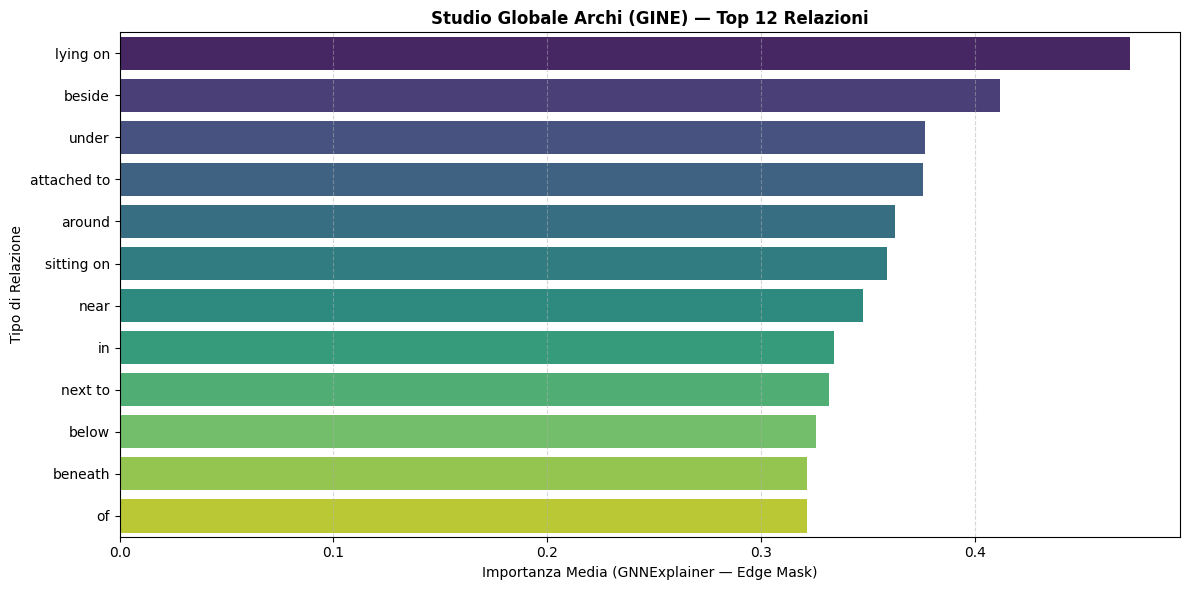

In [12]:
# NUM_SAMPLES_PER_CLASS campioni per ogni classe (stesso valore usato per Grad-CAM)
df_edges_gine = analyze_global_edge_importance_with_explainer(
    dataset_gine=val_dataset_gine,
    model_gine=gine_model,
    rel_vocab_gine=rel_vocab_gine,
    device=device,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,  # <-- stratificato
    df=df_val,
    prototypes=prototypes_gine,                   # <-- fix TypeError
)

df_edges_gine_clean = df_edges_gine[df_edges_gine['Conteggio'] >= 5]
print(df_edges_gine_clean.head(12))
plot_global_edge_study(df_edges_gine_clean, topk=12, model_name="GINE")


## 3 · Studio Globale Archi — GCN (GNNExplainer)

Stesso approccio per il modello GCN, con campionamento stratificato.

Analisi archi (GCN — GNNExplainer) su 140 campioni stratificati (10 per classe)...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


                    Relazione  Importanza Media  Conteggio
0               cliff → cliff          0.528188          8
1             wing → airplane          0.518222          6
2     toothbrush → toothbrush          0.514850          8
3               pipe → toilet          0.505853          6
4           cabinet → cabinet          0.491687         28
5              flowers → vase          0.474258          5
6         airplane → airplane          0.467934         12
7             tail → airplane          0.466333          5
8   toilet bowl → toilet bowl          0.459516         12
9                boat → water          0.450133         12
10            airplane → tail          0.449305          5
11                man → purse          0.449281          6
12           airplane → wings          0.447334          5
13                  ear → ear          0.446267         16
14                sign → post          0.438872          6


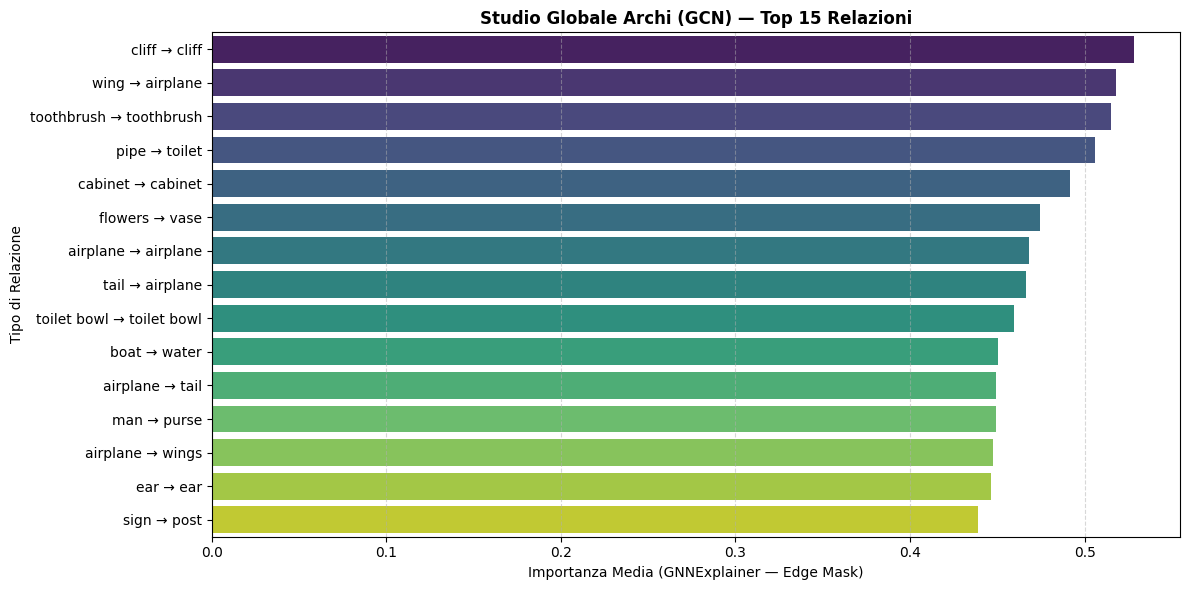

In [13]:
df_edges_gcn = analyze_global_edge_importance_gcn(
    dataset_gcn=val_dataset_gcn,
    model_gcn=gcn_model,
    node_vocab_gcn=node_vocab_gcn,
    device=device,
    min_count=5,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,  # <-- stratificato
    df=df_val,
    prototypes=prototypes_gcn,                    # <-- fix TypeError
)

df_edges_gcn = df_edges_gcn[df_edges_gcn['Conteggio'] >= 5]
print(df_edges_gcn.head(15))
plot_global_edge_study(df_edges_gcn, topk=15, model_name="GCN")


## 4 · Focal Point Analysis — Impatto Causale sul Ranking

Le sezioni precedenti misurano correlazioni tra struttura del grafo e output.
La **Focal Point Analysis** risponde alla domanda causale:

> *"Se questa relazione non esistesse, il ranking dei vicini cambierebbe?"*

Ogni tipo di relazione viene rimosso dall'input e si misura la disruption
del top-k ranking nello spazio metrico.

**Step 1** — costruiamo la gallery degli embedding sul validation set.

In [14]:
print("Building GCN gallery embeddings...")
gallery_embs_gcn  = build_gallery_embeddings(
    gcn_model, val_dataset_gcn, device, model_type="gcn"
)
print("Building GINE gallery embeddings...")
gallery_embs_gine = build_gallery_embeddings(
    gine_model, val_dataset_gine, device, model_type="gine"
)
print(f"Gallery GCN:  {gallery_embs_gcn.shape}")
print(f"Gallery GINE: {gallery_embs_gine.shape}")


Building GCN gallery embeddings...
Building GINE gallery embeddings...
Gallery GCN:  torch.Size([3208, 128])
Gallery GINE: torch.Size([3208, 128])


### 4a · Robustness by Relation Type — Delta Embedding

Prima misura: quanto si sposta l'embedding (norma L2) quando si rimuove
ogni tipo di relazione. Un delta alto = relazione strutturalmente critica.

In [15]:
from src.utils.GraphGradCAM import robustness_by_relation_type_gcn, focal_point_analysis_gcn

NUM_SAMPLES = 100
TOPK        = 10



In [16]:
print("Calcolo spostamento degli embedding (Delta L2) su GCN...")
robustness_gcn_series = robustness_by_relation_type_gcn(
    model=gcn_model,
    dataset=val_dataset_gcn,
    node_vocab=node_vocab_gcn,
    device=device,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,  # <-- stratificato
    df=df_val,
)

df_robustness_gcn = robustness_gcn_series.reset_index()
df_robustness_gcn.columns = ['Relazione', 'Importanza Media']
print("\n[Top Spostamenti dell'Embedding (Delta L2) - GCN]")
print(df_robustness_gcn.head(10))


Calcolo spostamento degli embedding (Delta L2) su GCN...

[Top Spostamenti dell'Embedding (Delta L2) - GCN]
              Relazione  Importanza Media
0        airplane → fan          0.665583
1        fan → airplane          0.652475
2  dishwasher → counter          0.574990
3           cat → chair          0.561175
4         beach → horse          0.554258
5         horse → beach          0.545004
6  counter → dishwasher          0.503478
7          bed → kettle          0.486910
8           chair → cat          0.484111
9       ottoman → chair          0.458662


In [17]:
print("Robustness GINE...")
rob_gine = robustness_by_relation_type(
    gine_model, val_dataset_gine, rel_vocab_gine, device,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,  # <-- stratificato
    df=df_val,
    model_type="gine",
)
print("\nTop-10 relazioni critiche (delta embedding) — GINE:")
print(rob_gine.head(10).to_string())


Robustness GINE...

Top-10 relazioni critiche (delta embedding) — GINE:
to the left of     0.100522
to the right of    0.089225
on                 0.054153
in                 0.032682
wearing            0.016442
of                 0.010403
near               0.009403
above              0.008850
below              0.005622
next to            0.004817


### 4b · Focal Point Analysis — Ranking Disruption

Misura più rilevante per retrieval: quanto cambia il top-k ranking
quando si rimuove ogni tipo di relazione.

`Disruption = 1 − overlap(top-k base, top-k perturbed)`

In [18]:
print("Focal Point Analysis — GINE...")
focal_gine = focal_point_analysis(
    gine_model, val_dataset_gine, gallery_embs_gine, rel_vocab_gine,
    device=device,
    topk=TOPK,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,  # <-- stratificato
    df=df_val,
    model_type="gine",
)
print("\nTop-10 focal point relazioni — GINE:")
print(focal_gine.head(15).to_string())


Focal Point Analysis — GINE...
Focal Point Analysis (GINE) su 140 campioni stratificati (10 per classe)...

Top-10 focal point relazioni — GINE:
to the left of     0.480000
to the right of    0.448148
on                 0.218657
in                 0.120896
wearing            0.094074
near               0.061481
of                 0.059701
in front of        0.029630
below              0.029630
above              0.029630
on top of          0.025185
behind             0.025185
with               0.017778
next to            0.016296
by                 0.015556


In [19]:
print("Esecuzione Focal Point Analysis su GCN...")
focal_gcn_series = focal_point_analysis_gcn(
    model=gcn_model,
    dataset=val_dataset_gcn,
    gallery_embs=gallery_embs_gcn,
    node_vocab=node_vocab_gcn,
    device=device,
    topk=TOPK,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,  # <-- stratificato
    df=df_val,
)

df_focal_gcn = focal_gcn_series.reset_index()
df_focal_gcn.columns = ['Relazione', 'Importanza Media']
print("\nTop 10 Focal Points Critici (GCN):")
print(df_focal_gcn.head(15))


Esecuzione Focal Point Analysis su GCN...
Focal Point Analysis (GCN) su 140 campioni stratificati (10 per classe)...

Top 10 Focal Points Critici (GCN):
         Relazione  Importanza Media
0    leaves → tree          0.700000
1      sky → cloud          0.560000
2      cloud → sky          0.540000
3    tree → leaves          0.540000
4     clouds → sky          0.433333
5     sky → clouds          0.400000
6     water → boat          0.360000
7      hand → wall          0.360000
8      wall → hair          0.340000
9     boat → water          0.340000
10     tree → tree          0.337500
11     wall → hand          0.280000
12  woman → person          0.260000
13   hair → window          0.250000
14       hat → man          0.240000
